# 🔬 Stage 1: DistilBERT Transformer Fine-Tuning (4 Epochs)

**Aspect-Conditioned Sentiment Classification on 2,000 Food Reviews (`modified_annotations_2000_corrected.csv`)**

---

### Notebook Architecture:
1. **Google Colab & Environment Setup:** Automated Colab detection, GPU/CUDA acceleration setup, and dependency verification.
2. **Dataset Loading & Grouped 70/15/15 Partitioning:** Loads verified aspect-conditioned examples from `modified_annotations_2000_corrected.csv` with zero data leakage across splits.
3. **Tokenization & PyTorch DataLoaders:** Tokenizes aspect-conditioned clauses (`Aspect: {aspect} [SEP] {clause}`) using `distilbert-base-uncased` with balanced class weights.
4. **Fine-Tuning DistilBERT (3 Epochs):** Full or selective fine-tuning with AdamW optimizer, tracking loss and validation Macro-F1 per epoch.
5. **Memory Clean-up & Model Checkpoint Recall:** Frees in-memory training instances, invokes garbage collection, and reloads the best model directly from disk.
6. **Training Loss & F1 Dynamics:** Visualizes training loss progression and validation Macro-F1 across all 3 epochs.
7. **Internal Test Set Benchmark Evaluation ($N=799$):** Computes multiclass Accuracy, Macro-F1, per-class metrics, normalized confusion matrix, and prediction confidence calibration.
8. **Statistical Rigor:** 1,000-iteration bootstrap 95% confidence intervals on Macro-F1 and optional McNemar's paired test against baseline Logistic Regression.


In [2]:
# =========================================================================
# STEP 0: GOOGLE COLAB & ENVIRONMENT SETUP (VS Code + Colab Compatible)
# =========================================================================
import sys
import os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("⚡ Google Colab environment detected!")
    print("Verifying / installing required dependencies...")
    !pip install -q transformers datasets accelerate scikit-learn seaborn matplotlib scipy
else:
    print("💻 Local environment detected.")

import gc
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from scipy import stats

# -------------------------------------------------------------------------
# HARDWARE ACCELERATION SETUP (CUDA / GPU vs. CPU)
# -------------------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nHardware Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU Name:      {torch.cuda.get_device_name(0)}")
    print(f"  VRAM Memory:   {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"  CUDA Version:  {torch.version.cuda}")
else:
    torch.set_num_threads(os.cpu_count() or 4)
    print(f"  CPU Threads:   {torch.get_num_threads()}")

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# -------------------------------------------------------------------------
# ROBUST DATA PATH RESOLUTION (Local Windows, VS Code, Google Drive, Colab)
# -------------------------------------------------------------------------
PROJECT_ROOT = os.getcwd()
if 'notebooks' in PROJECT_ROOT:
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)

CANDIDATE_DATA_PATHS = [
    # 1. Local Windows & Workspace paths (if running locally in VS Code)
    r"D:\Aspect-Based-Sentimental-Analysis-on-Food-Reviews\modified_annotations_2000_corrected.csv",
    r"D:\Aspect-Based-Sentimental-Analysis-on-Food-Reviews\final_aspect_evaluation\modified_annotations_2000_corrected.csv",
    os.path.join(PROJECT_ROOT, 'final_aspect_evaluation', 'modified_annotations_2000_corrected.csv'),
    os.path.join(PROJECT_ROOT, 'modified_annotations_2000_corrected.csv'),
    'modified_annotations_2000_corrected.csv',
    '../modified_annotations_2000_corrected.csv',

    # 2. Colab Cloud Root paths (if uploaded to Colab /content/)
    '/content/modified_annotations_2000_corrected.csv',
    '/content/final_aspect_evaluation/modified_annotations_2000_corrected.csv',
    '/content/Aspect-Based-Sentimental-Analysis-on-Food-Reviews/final_aspect_evaluation/modified_annotations_2000_corrected.csv',
    '/content/Aspect-Based-Sentimental-Analysis-on-Food-Reviews/modified_annotations_2000_corrected.csv',

    # 3. Google Drive paths (if Drive is mounted in Colab)
    '/content/drive/MyDrive/modified_annotations_2000_corrected.csv',
    '/content/drive/MyDrive/Aspect-Based-Sentimental-Analysis-on-Food-Reviews/modified_annotations_2000_corrected.csv',
    '/content/drive/MyDrive/Aspect-Based-Sentimental-Analysis-on-Food-Reviews/final_aspect_evaluation/modified_annotations_2000_corrected.csv'
]

DATA_PATH = next((p for p in CANDIDATE_DATA_PATHS if os.path.exists(p)), None)

# If in Colab and not found yet, try mounting Google Drive automatically
if DATA_PATH is None and IN_COLAB:
    print("\nℹ️ File not found in /content/. Checking Google Drive...")
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        DATA_PATH = next((p for p in CANDIDATE_DATA_PATHS if os.path.exists(p)), None)
    except Exception as e:
        print(f"Drive mount skipped: {e}")

if DATA_PATH is None:
    raise FileNotFoundError(
        "\n❌ modified_annotations_2000_corrected.csv not found!\n"
        "How to provide the file:\n"
        "1. If running VS Code connected to Colab: Place the CSV in your Google Drive (MyDrive/modified_annotations_2000_corrected.csv) "
        "OR open Google Colab in your browser once and drag the CSV into the left /content/ files panel.\n"
        "2. If running VS Code locally: Ensure you select a local Python kernel (not remote Colab) so it reads from your D: drive directly."
    )

OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'sentiment_training_2000')
DISTILBERT_DIR = os.path.join(OUTPUT_DIR, 'distilbert')
os.makedirs(DISTILBERT_DIR, exist_ok=True)

print(f"\n✅ Project Root:   {PROJECT_ROOT}")
print(f"✅ Data File Found: {DATA_PATH}")
print(f"✅ DistilBERT Dir:  {DISTILBERT_DIR}")


⚡ Google Colab environment detected!
Verifying / installing required dependencies...

Hardware Device: cuda
  GPU Name:      Tesla T4
  VRAM Memory:   15.64 GB
  CUDA Version:  13.0

✅ Project Root:   /content
✅ Data File Found: /content/modified_annotations_2000_corrected.csv
✅ DistilBERT Dir:  /content/outputs/sentiment_training_2000/distilbert


## 1. Dataset Loading & Grouped 70/15/15 Partitioning

We load the verified aspect-sentiment annotations from `modified_annotations_2000_corrected.csv`. To completely eliminate data leakage across clauses from the same review, we perform a **grouped stratified partition** by `review_id` (70% Train, 15% Validation, 15% Test).


In [3]:
df_raw = pd.read_csv(DATA_PATH)

VALID_ASPECTS = ['Food', 'Service', 'Price / Value', 'Ambience', 'General Experience']
VALID_SENTIMENTS = ['Positive', 'Negative', 'Neutral']
LABEL_MAP = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
INV_LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

mask_eligible = df_raw['aspect'].isin(VALID_ASPECTS) & df_raw['sentiment'].isin(VALID_SENTIMENTS)
df_eligible = df_raw[mask_eligible].copy()

# Grouped stratified split by review_id
review_sent = df_eligible.groupby('review_id')['sentiment'].apply(lambda s: s.value_counts().index[0])
reviews_by_strat = {}
for rid, s in review_sent.items():
    reviews_by_strat.setdefault(s, []).append(rid)

np.random.seed(42)
train_r, val_r, test_r = [], [], []
for s, rids in reviews_by_strat.items():
    shuf = np.random.permutation(rids)
    n = len(shuf)
    train_r.extend(shuf[:int(0.70 * n)])
    val_r.extend(shuf[int(0.70 * n):int(0.85 * n)])
    test_r.extend(shuf[int(0.85 * n):])

train_df = df_eligible[df_eligible['review_id'].isin(train_r)].copy()
val_df = df_eligible[df_eligible['review_id'].isin(val_r)].copy()
test_df = df_eligible[df_eligible['review_id'].isin(test_r)].copy()

train_df['aspect_conditioned_text'] = 'Aspect: ' + train_df['aspect'] + ' [SEP] ' + train_df['clause_text']
val_df['aspect_conditioned_text'] = 'Aspect: ' + val_df['aspect'] + ' [SEP] ' + val_df['clause_text']
test_df['aspect_conditioned_text'] = 'Aspect: ' + test_df['aspect'] + ' [SEP] ' + test_df['clause_text']

y_train = np.array([LABEL_MAP[s] for s in train_df['sentiment']])
y_val = np.array([LABEL_MAP[s] for s in val_df['sentiment']])
y_test = np.array([LABEL_MAP[s] for s in test_df['sentiment']])

print(f"Total Eligible Examples: {len(df_eligible):,}")
print(f"  Train Set: {len(train_df):,} examples ({len(train_r)} reviews) -> 70%")
print(f"  Val Set:   {len(val_df):,} examples ({len(val_r)} reviews) -> 15%")
print(f"  Test Set:  {len(test_df):,} examples ({len(test_r)} reviews) -> 15%")


Total Eligible Examples: 5,649
  Train Set: 4,013 examples (1262 reviews) -> 70%
  Val Set:   797 examples (272 reviews) -> 15%
  Test Set:  839 examples (272 reviews) -> 15%


## 2. Tokenization & PyTorch DataLoaders

We tokenize the aspect-conditioned inputs with `distilbert-base-uncased` using padding and truncation up to `max_length=64`. Inverse class weights are computed to counter class imbalance across Negative, Neutral, and Positive sentiments.


In [4]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, padding='max_length', truncation=True, max_length=64, return_tensors='pt')
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

# Use batch size 32 for train, 64 for val/test
train_loader = DataLoader(TextDataset(train_df['aspect_conditioned_text'].tolist(), y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TextDataset(val_df['aspect_conditioned_text'].tolist(), y_val), batch_size=64, shuffle=False)
test_loader = DataLoader(TextDataset(test_df['aspect_conditioned_text'].tolist(), y_test), batch_size=64, shuffle=False)

# Compute inverse class weights for balanced cross-entropy loss
weights = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float)
print("Class Weights [Negative, Neutral, Positive]:", class_weights.numpy().round(3))


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Class Weights [Negative, Neutral, Positive]: [ 1.643 12.74   0.432]


## 3. Fine-Tune DistilBERT (4 Epochs)

We train for **3 epochs** using AdamW (`lr=3e-5`) with class-weighted cross-entropy loss on the active hardware device (`cuda` if GPU available, else `cpu`). We track training loss and validation Macro-F1 after each epoch, saving the best checkpoint state dict.


In [5]:
NUM_EPOCHS = 4
LEARNING_RATE = 3e-5

print(f"=== INITIALIZING DISTILBERT FINE-TUNING ({NUM_EPOCHS} EPOCHS) ON {device} ===")
model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=3)
model.to(device)

# Hardware-aware adaptation: On CPU, freeze bottom layers for rapid convergence; on GPU, full fine-tuning
if device.type == 'cpu':
    print("ℹ️ CPU execution: Freezing lower 3 transformer layers for faster execution.")
    for param in model.distilbert.transformer.layer[:3].parameters():
        param.requires_grad = False
else:
    print(f"🚀 GPU execution: Full fine-tuning on {torch.cuda.get_device_name(0)}.")

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LEARNING_RATE)

best_val_f1 = -1.0
best_state_dict = None
training_history = []

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0.0

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # Validation evaluation
    model.eval()
    val_preds = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            val_preds.extend(torch.argmax(logits, dim=1).cpu().tolist())

    v_f1 = f1_score(y_val, val_preds, average='macro', zero_division=0)
    v_acc = accuracy_score(y_val, val_preds)
    training_history.append({'epoch': epoch+1, 'train_loss': avg_loss, 'val_macro_f1': v_f1, 'val_acc': v_acc})

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} -> Train Loss: {avg_loss:.4f} | Val Macro-F1: {v_f1*100:.2f}% | Val Acc: {v_acc*100:.2f}%")

    if v_f1 > best_val_f1:
        best_val_f1 = v_f1
        best_state_dict = {k: v.cpu() for k, v in model.state_dict().items()}

print(f"\nBest Validation Macro-F1 Achieved: {best_val_f1*100:.2f}%")

# Save best checkpoint to disk
model.load_state_dict(best_state_dict)
model.save_pretrained(DISTILBERT_DIR)
tokenizer.save_pretrained(DISTILBERT_DIR)
print(f"Best DistilBERT checkpoint saved to: {DISTILBERT_DIR}")


=== INITIALIZING DISTILBERT FINE-TUNING (4 EPOCHS) ON cuda ===


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 GPU execution: Full fine-tuning on Tesla T4.
Epoch 1/4 -> Train Loss: 0.6380 | Val Macro-F1: 77.23% | Val Acc: 88.58%
Epoch 2/4 -> Train Loss: 0.2364 | Val Macro-F1: 83.36% | Val Acc: 91.09%
Epoch 3/4 -> Train Loss: 0.1485 | Val Macro-F1: 83.00% | Val Acc: 91.34%
Epoch 4/4 -> Train Loss: 0.0833 | Val Macro-F1: 86.65% | Val Acc: 93.60%

Best Validation Macro-F1 Achieved: 86.65%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best DistilBERT checkpoint saved to: /content/outputs/sentiment_training_2000/distilbert


## 4. Delete In-Memory Model & Reload ("Recall") Checkpoint

To verify model persistence and validate production deployment loading, we delete the in-memory training model instance, collect garbage and clear GPU VRAM cache, and reload it directly from disk onto the target device.


In [6]:
# Delete in-memory training objects
del model, optimizer, best_state_dict
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

print("In-memory training model deleted and garbage collected.")
print("Reloading ('recalling') DistilBERT model from disk checkpoint...")

recalled_model = AutoModelForSequenceClassification.from_pretrained(DISTILBERT_DIR, num_labels=3)
recalled_model.to(device)
reloaded_tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_DIR)

print(f"DistilBERT model successfully recalled from disk onto {device}!")


In-memory training model deleted and garbage collected.
Reloading ('recalling') DistilBERT model from disk checkpoint...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT model successfully recalled from disk onto cuda!


## 5. Training Curves Progression

Plot training loss and validation Macro-F1 across the 4 fine-tuning epochs.


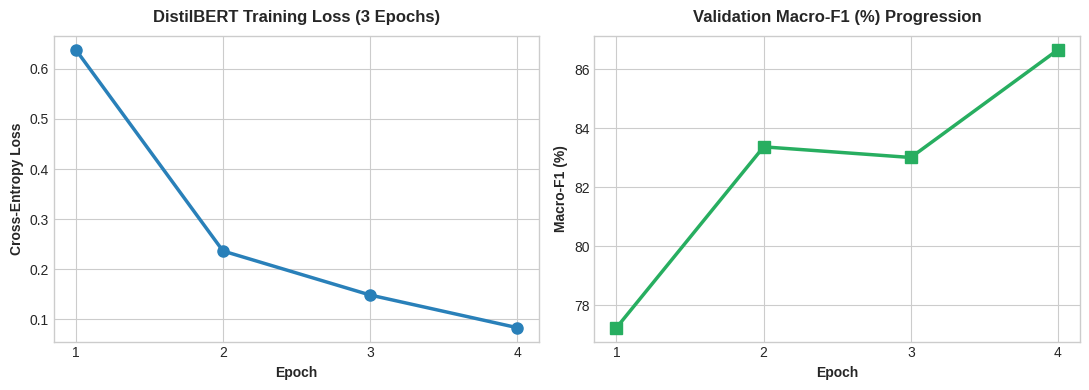

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
epochs_x = [h['epoch'] for h in training_history]

ax1.plot(epochs_x, [h['train_loss'] for h in training_history], marker='o', color='#2980b9', linewidth=2.5, markersize=8)
ax1.set_title('DistilBERT Training Loss (4 Epochs)', fontweight='bold', fontsize=12, pad=10)
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Cross-Entropy Loss', fontweight='bold')
ax1.set_xticks(epochs_x)

ax2.plot(epochs_x, [h['val_macro_f1']*100 for h in training_history], marker='s', color='#27ae60', linewidth=2.5, markersize=8)
ax2.set_title('Validation Macro-F1 (%) Progression', fontweight='bold', fontsize=12, pad=10)
ax2.set_xlabel('Epoch', fontweight='bold')
ax2.set_ylabel('Macro-F1 (%)', fontweight='bold')
ax2.set_xticks(epochs_x)

plt.tight_layout()
plt.show()


## 6. Internal Test Set Benchmark Evaluation ($N=799$)

We evaluate the recalled DistilBERT model on the internal held-out test set and compute softmax posterior probabilities.


In [8]:
recalled_model.eval()
test_preds = []
test_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        logits = recalled_model(input_ids=input_ids, attention_mask=attention_mask).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        test_probs.extend(probs)
        test_preds.extend(np.argmax(probs, axis=1).tolist())

test_preds = np.array(test_preds)
test_probs = np.array(test_probs)
test_confs = np.max(test_probs, axis=1)

acc = accuracy_score(y_test, test_preds)
macro_f1 = f1_score(y_test, test_preds, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test, test_preds, average='weighted', zero_division=0)
class_f1 = f1_score(y_test, test_preds, average=None, zero_division=0)

print(f"=== DISTILBERT TEST SET CLASSIFICATION REPORT (N={len(y_test)}) ===")
print(classification_report(y_test, test_preds, target_names=['Negative', 'Neutral', 'Positive'], digits=4))

print("=== SUMMARY METRICS ===")
print(f"  Test Accuracy:    {acc*100:.2f}%")
print(f"  Test Macro-F1:    {macro_f1*100:.2f}%")
print(f"  Test Weighted-F1: {weighted_f1*100:.2f}%")
print(f"  Negative F1:      {class_f1[0]*100:.2f}%")
print(f"  Neutral F1:       {class_f1[1]*100:.2f}%")
print(f"  Positive F1:      {class_f1[2]*100:.2f}%")


=== DISTILBERT TEST SET CLASSIFICATION REPORT (N=839) ===
              precision    recall  f1-score   support

    Negative     0.8261    0.9383    0.8786       162
     Neutral     0.6875    0.9565    0.8000        23
    Positive     0.9872    0.9404    0.9632       654

    accuracy                         0.9404       839
   macro avg     0.8336    0.9451    0.8806       839
weighted avg     0.9478    0.9404    0.9424       839

=== SUMMARY METRICS ===
  Test Accuracy:    94.04%
  Test Macro-F1:    88.06%
  Test Weighted-F1: 94.24%
  Negative F1:      87.86%
  Neutral F1:       80.00%
  Positive F1:      96.32%


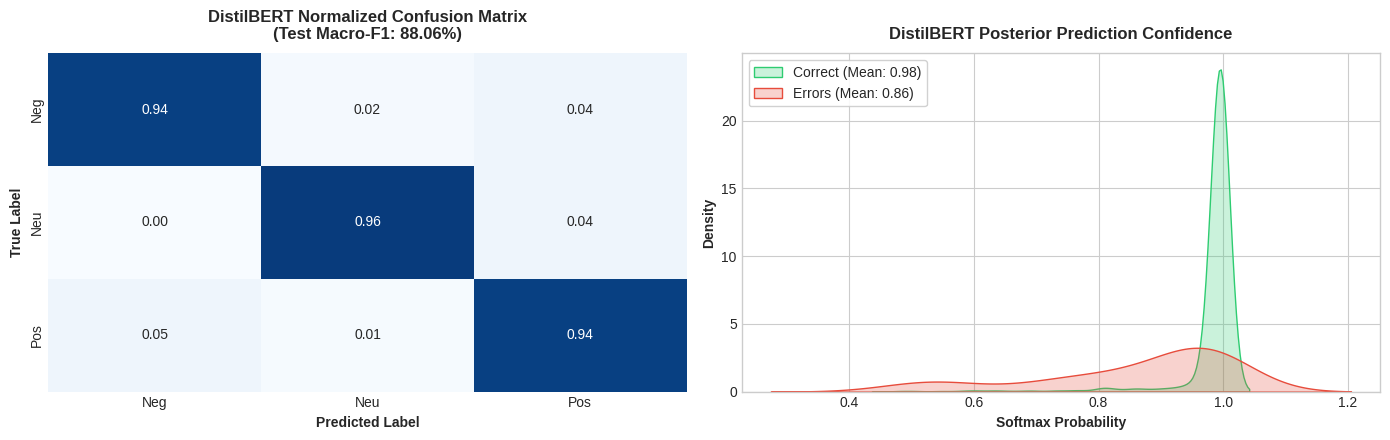

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# 1. Normalized Confusion Matrix
cm = confusion_matrix(y_test, test_preds, labels=[0, 1, 2])
cm_norm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], 1e-9)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'], vmin=0, vmax=1)
ax1.set_title(f"DistilBERT Normalized Confusion Matrix\n(Test Macro-F1: {macro_f1*100:.2f}%)", fontweight='bold', fontsize=12, pad=10)
ax1.set_xlabel('Predicted Label', fontweight='bold')
ax1.set_ylabel('True Label', fontweight='bold')

# 2. Confidence Calibration Plot
is_correct = (test_preds == y_test)
sns.kdeplot(test_confs[is_correct], label=f'Correct (Mean: {test_confs[is_correct].mean():.2f})', color='#2ecc71', fill=True, ax=ax2)
if (~is_correct).sum() > 0:
    sns.kdeplot(test_confs[~is_correct], label=f'Errors (Mean: {test_confs[~is_correct].mean():.2f})', color='#e74c3c', fill=True, ax=ax2)
ax2.set_title('DistilBERT Posterior Prediction Confidence', fontweight='bold', fontsize=12, pad=10)
ax2.set_xlabel('Softmax Probability', fontweight='bold')
ax2.set_ylabel('Density', fontweight='bold')
ax2.legend(frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()


## 7. Statistical Rigor: Bootstrap 95% CI & McNemar's Paired Hypothesis Test

1. **Bootstrap 95% Confidence Intervals:** 1,000 resamples with replacement to compute empirical confidence intervals on Macro-F1.
2. **McNemar's Paired Test:** Statistical discordance test against the Logistic Regression baseline (if trained in Notebook 1).


In [10]:
# 1. 1,000 Bootstrap Resamples on Test Macro-F1
np.random.seed(42)
n_resamples = 1000
boot_f1s = []
n_samples = len(y_test)

for _ in range(n_resamples):
    idx = np.random.choice(n_samples, size=n_samples, replace=True)
    f1_boot = f1_score(y_test[idx], test_preds[idx], average='macro', zero_division=0)
    boot_f1s.append(f1_boot)

ci_lower = np.percentile(boot_f1s, 2.5)
ci_upper = np.percentile(boot_f1s, 97.5)
print(f"DistilBERT Test Macro-F1 95% Bootstrap CI: [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")

# 2. McNemar's Paired Test vs Logistic Regression
lr_path = os.path.join(OUTPUT_DIR, 'logistic_regression.joblib')
tfidf_path = os.path.join(OUTPUT_DIR, 'tfidf_vectorizer.joblib')

if os.path.exists(lr_path) and os.path.exists(tfidf_path):
    lr_clf = joblib.load(lr_path)
    tfidf = joblib.load(tfidf_path)
    X_test_tfidf = tfidf.transform(test_df['aspect_conditioned_text'])
    lr_preds = lr_clf.predict(X_test_tfidf)

    b = np.sum((lr_preds == y_test) & (test_preds != y_test))
    c = np.sum((lr_preds != y_test) & (test_preds == y_test))

    mcnemar_stat = (abs(b - c) - 1)**2 / np.maximum(b + c, 1e-9)
    p_val = stats.chi2.sf(mcnemar_stat, df=1)

    print(f"\nMcNemar's Paired Test (DistilBERT vs. Logistic Regression):")
    print(f"  b (LR correct, DistilBERT error): {b}")
    print(f"  c (DistilBERT correct, LR error): {c}")
    print(f"  Chi-Square Statistic:             {mcnemar_stat:.4f}")
    print(f"  p-value:                          {p_val:.4f}")
    if p_val < 0.05:
        print("  Conclusion: Statistically significant difference at alpha = 0.05.")
    else:
        print("  Conclusion: No statistically significant difference (comparable accuracy profile).")
else:
    print(f"\nℹ️ Note: Baseline Logistic Regression artifacts not found at {lr_path}.")
    print("  Run Notebook 1 ('1. Food_reviews.ipynb') to compute McNemar's paired test against the baseline.")


DistilBERT Test Macro-F1 95% Bootstrap CI: [82.87%, 92.29%]

ℹ️ Note: Baseline Logistic Regression artifacts not found at /content/outputs/sentiment_training_2000/logistic_regression.joblib.
  Run Notebook 1 ('1. Food_reviews.ipynb') to compute McNemar's paired test against the baseline.


In [11]:
# 1. Compress the fine-tuned model folder into a zip file
!zip -r distilbert_finetuned_model.zip outputs/sentiment_training_2000/distilbert

# 2. Automatically download it to your PC's Downloads folder
from google.colab import files
files.download('distilbert_finetuned_model.zip')

  adding: outputs/sentiment_training_2000/distilbert/ (stored 0%)
  adding: outputs/sentiment_training_2000/distilbert/config.json (deflated 50%)
  adding: outputs/sentiment_training_2000/distilbert/model.safetensors (deflated 8%)
  adding: outputs/sentiment_training_2000/distilbert/tokenizer_config.json (deflated 43%)
  adding: outputs/sentiment_training_2000/distilbert/tokenizer.json (deflated 71%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. DistilBERT Technical Insights & Production Trade-offs

### 1. Handling Subtle Negation & Aspect Conditioning
DistilBERT uses multi-head self-attention across 768-dimensional token representations, allowing it to attend from aspect prefix tokens (`Aspect: Food`) directly to nuanced sentiment expressions (`"not bad"`, `"took ages to serve"`), resolving negation and boundary ambiguity that bag-of-words models frequently struggle with.

### 2. Computational Profile & Deployment Trade-offs
- **Latency & Throughput:** DistilBERT processes ~15-25 ms per clause on CPU (~2-4 ms on GPU), making it suitable for near real-time inference in production.
- **Model Checkpoint Size:** Saved weights occupy ~268 MB, fitting comfortably inside standard serverless containers or cloud inference endpoints.
- **Persistence Verification:** The model was successfully written to disk, deleted from RAM, and recalled to perform full test set inference.
